In [1]:
# Instala dependências
!pip install -q kaggle

# Verifica GPU
import torch
print(f"GPU disponível: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'torch'

In [3]:
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader, Subset
import numpy as np

# Download automático do EuroSAT via torchvision
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = EuroSAT(root='./data', transform=transform, download=True)

print(f"Classes: {dataset.classes}")
print(f"Total de imagens: {len(dataset)}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total de imagens: 27000


In [10]:
# CÉLULA 3 — Filtrar 4 classes e criar splits
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

class EuroSATSubset(Dataset):
    def __init__(self, dataset, indices, label_map):
        self.dataset = dataset
        self.indices = indices
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return img, self.label_map[label]

classes_alvo = ['Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']
classes_idx  = [dataset.classes.index(c) for c in classes_alvo]
label_map    = {original: novo for novo, original in enumerate(classes_idx)}

indices = [i for i, (_, label) in enumerate(dataset) if label in classes_idx]
original_labels = [dataset.targets[i] for i in indices]

train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=original_labels)
temp_labels = [dataset.targets[i] for i in temp_idx]
val_idx, test_idx  = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

train_set = EuroSATSubset(dataset, train_idx, label_map)
val_set   = EuroSATSubset(dataset, val_idx,   label_map)
test_set  = EuroSATSubset(dataset, test_idx,  label_map)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)

print(f"Treino: {len(train_set)} | Validação: {len(val_set)} | Teste: {len(test_set)}")

Treino: 8400 | Validação: 1800 | Teste: 1800


In [11]:
# CÉLULA 4 — Definir arquiteturas CNN
import torch.nn as nn

class CNN1(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class CNN2(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device("cuda")
model1 = CNN1().to(device)
model2 = CNN2().to(device)

print("CNN1:", sum(p.numel() for p in model1.parameters()), "parâmetros")
print("CNN2:", sum(p.numel() for p in model2.parameters()), "parâmetros")

CNN1: 2191684 parâmetros
CNN2: 2489092 parâmetros


In [12]:
# CÉLULA 5 — Função de treino
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

def treinar(model, train_loader, val_loader, epochs=15, nome="modelo"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    historico = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)
            total_correct += (out.argmax(1) == y).sum().item()
            total += X.size(0)

        train_loss = total_loss / total
        train_acc  = total_correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                val_loss += criterion(out, y).item() * X.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += X.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total
        scheduler.step()

        historico["train_loss"].append(train_loss)
        historico["train_acc"].append(train_acc)
        historico["val_loss"].append(val_loss)
        historico["val_acc"].append(val_acc)

        print(f"[{nome}] Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2%}")

    return historico

In [13]:
model1 = CNN1().to(device)
model2 = CNN2().to(device)

print("Treinando CNN1...")
hist1 = treinar(model1, train_loader, val_loader, nome="CNN1")
print("\nTreinando CNN2...")
hist2 = treinar(model2, train_loader, val_loader, nome="CNN2")

Treinando CNN1...
[CNN1] Epoch 01/15 | Train Loss: 0.4933 Acc: 78.83% | Val Loss: 0.2512 Acc: 90.78%
[CNN1] Epoch 02/15 | Train Loss: 0.2751 Acc: 89.70% | Val Loss: 0.1509 Acc: 94.83%
[CNN1] Epoch 03/15 | Train Loss: 0.1949 Acc: 93.05% | Val Loss: 0.2043 Acc: 90.67%
[CNN1] Epoch 04/15 | Train Loss: 0.1865 Acc: 93.42% | Val Loss: 0.1537 Acc: 95.00%
[CNN1] Epoch 05/15 | Train Loss: 0.1296 Acc: 95.46% | Val Loss: 0.1053 Acc: 96.06%
[CNN1] Epoch 06/15 | Train Loss: 0.0698 Acc: 97.37% | Val Loss: 0.0499 Acc: 98.17%
[CNN1] Epoch 07/15 | Train Loss: 0.0620 Acc: 97.67% | Val Loss: 0.0553 Acc: 98.11%
[CNN1] Epoch 08/15 | Train Loss: 0.0501 Acc: 98.24% | Val Loss: 0.0678 Acc: 97.78%
[CNN1] Epoch 09/15 | Train Loss: 0.0460 Acc: 98.33% | Val Loss: 0.0274 Acc: 99.06%
[CNN1] Epoch 10/15 | Train Loss: 0.0459 Acc: 98.44% | Val Loss: 0.0360 Acc: 98.67%
[CNN1] Epoch 11/15 | Train Loss: 0.0264 Acc: 99.07% | Val Loss: 0.0395 Acc: 98.61%
[CNN1] Epoch 12/15 | Train Loss: 0.0215 Acc: 99.26% | Val Loss: 0.029


=== CNN1 — Teste ===
                      precision    recall  f1-score   support

              Forest       0.99      0.99      0.99       450
HerbaceousVegetation       0.99      0.95      0.97       450
         Residential       0.96      0.99      0.98       450
             SeaLake       1.00      1.00      1.00       450

            accuracy                           0.98      1800
           macro avg       0.98      0.98      0.98      1800
        weighted avg       0.98      0.98      0.98      1800


=== CNN2 — Teste ===
                      precision    recall  f1-score   support

              Forest       0.64      1.00      0.78       450
HerbaceousVegetation       0.97      0.98      0.97       450
         Residential       0.99      0.98      0.98       450
             SeaLake       1.00      0.45      0.62       450

            accuracy                           0.85      1800
           macro avg       0.90      0.85      0.84      1800
        weighted avg 

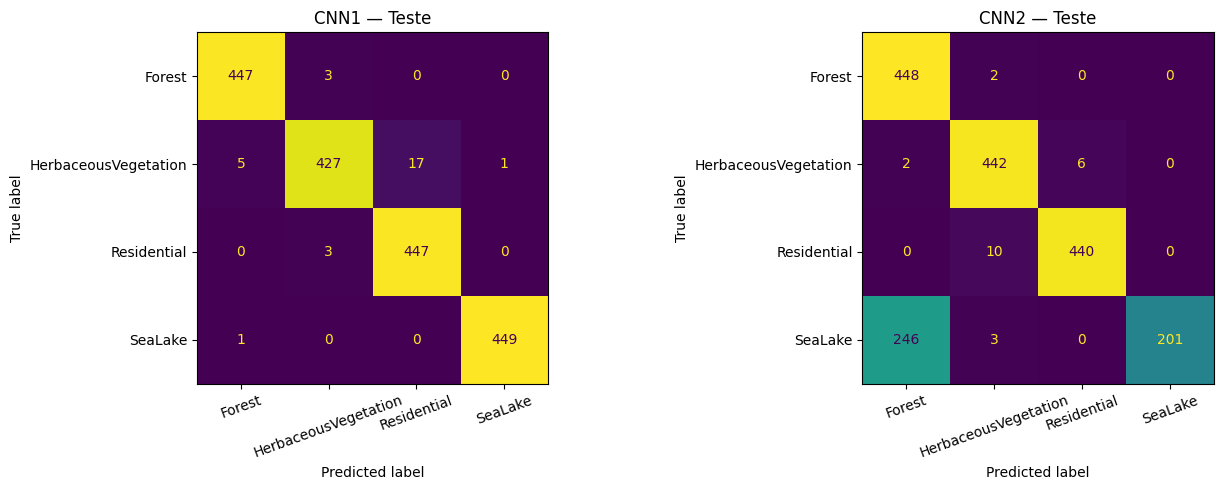

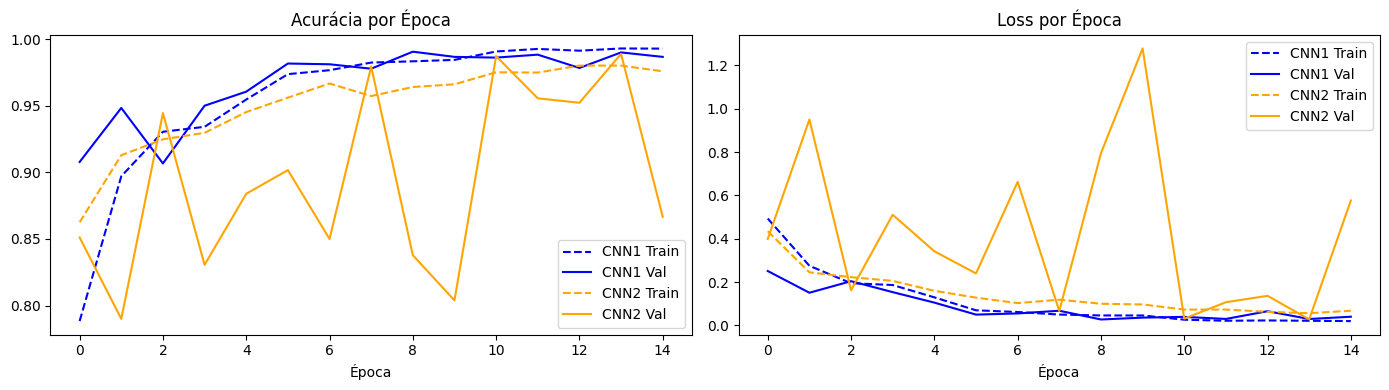

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Avaliação no conjunto de teste
def avaliar(model, loader, nome):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    print(f"\n=== {nome} — Teste ===")
    print(classification_report(all_labels, all_preds, target_names=classes_alvo))
    return all_preds, all_labels

preds1, labels1 = avaliar(model1, test_loader, "CNN1")
preds2, labels2 = avaliar(model2, test_loader, "CNN2")

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(labels1, preds1, display_labels=classes_alvo, ax=axes[0], colorbar=False, xticks_rotation=20)
axes[0].set_title("CNN1 — Teste")
ConfusionMatrixDisplay.from_predictions(labels2, preds2, display_labels=classes_alvo, ax=axes[1], colorbar=False, xticks_rotation=20)
axes[1].set_title("CNN2 — Teste")
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150)
plt.show()

# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for hist, nome, cor in [(hist1, "CNN1", "blue"), (hist2, "CNN2", "orange")]:
    axes[0].plot(hist["train_acc"], label=f"{nome} Train", linestyle="--", color=cor)
    axes[0].plot(hist["val_acc"],   label=f"{nome} Val",   linestyle="-",  color=cor)
    axes[1].plot(hist["train_loss"], label=f"{nome} Train", linestyle="--", color=cor)
    axes[1].plot(hist["val_loss"],   label=f"{nome} Val",   linestyle="-",  color=cor)

axes[0].set_title("Acurácia por Época"); axes[0].legend(); axes[0].set_xlabel("Época")
axes[1].set_title("Loss por Época");     axes[1].legend(); axes[1].set_xlabel("Época")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [15]:
import gradio as gr
from PIL import Image
import torchvision.transforms as transforms

# Salva o melhor modelo
torch.save(model1.state_dict(), "cnn1_best.pth")
print("Modelo salvo.")

# Transform para inferência (sem augmentation)
infer_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def classificar(imagem):
    tensor = infer_transform(imagem).unsqueeze(0).to(device)
    model1.eval()
    with torch.no_grad():
        probs = torch.softmax(model1(tensor), dim=1)[0]
    return {classes_alvo[i]: float(probs[i]) for i in range(4)}

gr.Interface(
    fn=classificar,
    inputs=gr.Image(type="pil", label="Imagem Satelital"),
    outputs=gr.Label(num_top_classes=4, label="Classificação"),
    title="OrbitWatch — Classificação de Cobertura de Solo",
    description="Envie uma imagem satelital para classificar: Floresta, Vegetação, Área Residencial ou Água."
).launch(share=True)

Modelo salvo.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cec8a9446c1b26e010.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Salva 1 imagem de teste de cada classe
test_samples = {}
for class_name in classes_alvo:
    class_folder = f"./data/eurosat/2750/{class_name}"
    img_file = os.listdir(class_folder)[0]
    img_path = f"{class_folder}/{img_file}"

    # Salva como PNG para download
    img = Image.open(img_path)
    img.save(f"test_{class_name}.png")
    test_samples[class_name] = img_path
    print(f"Salvo: test_{class_name}.png")

Salvo: test_Forest.png
Salvo: test_HerbaceousVegetation.png
Salvo: test_Residential.png
Salvo: test_SeaLake.png
